In [1]:
import numpy as np
import pandas as pd
study_hours = np.array([2,3,4,5,6,7,8,9,10,5,6,7,8,4,3,9,10,6])
attendance = np.array([55,60,65,70,75,80,85,90,95,68,78,88,92,62,58,94,97,82])
passed = np.array([0,0,0,0,1,1,1,1,1,0,1,1,1,0,0,1,1,1])
df = pd.DataFrame({"Study Hours": study_hours,"Attendance (%)": attendance,"Passed": passed})
print("Dataset")
print(df)

Dataset
    Study Hours  Attendance (%)  Passed
0             2              55       0
1             3              60       0
2             4              65       0
3             5              70       0
4             6              75       1
5             7              80       1
6             8              85       1
7             9              90       1
8            10              95       1
9             5              68       0
10            6              78       1
11            7              88       1
12            8              92       1
13            4              62       0
14            3              58       0
15            9              94       1
16           10              97       1
17            6              82       1


In [2]:
from sklearn.linear_model import LogisticRegression
X = df[["Study Hours", "Attendance (%)"]]
y = df["Passed"]

model = LogisticRegression()
model.fit(X, y)
new_student = np.array([[6, 80]])
prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

print("\nNew Student")
print(f"Study Hours : {new_student[0][0]}")
print(f"Attendance  : {new_student[0][1]}%")


New Student
Study Hours : 6
Attendance  : 80%


C:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [3]:
if prediction[0] == 1:
    print("Prediction : PASS")
else:
    print("Prediction : FAIL")

print(f"Fail Probability : {probability[0][0]*100:.2f}%")
print(f"Pass Probability : {probability[0][1]*100:.2f}%")

print("\nModel Coefficients")
print("Study Hours :", model.coef_[0][0])
print("Attendance  :", model.coef_[0][1])
print("Intercept   :", model.intercept_[0])

Prediction : PASS
Fail Probability : 0.26%
Pass Probability : 99.74%

Model Coefficients
Study Hours : 0.14005779739841462
Attendance  : 0.791210388027158
Intercept   : -58.18897348880973


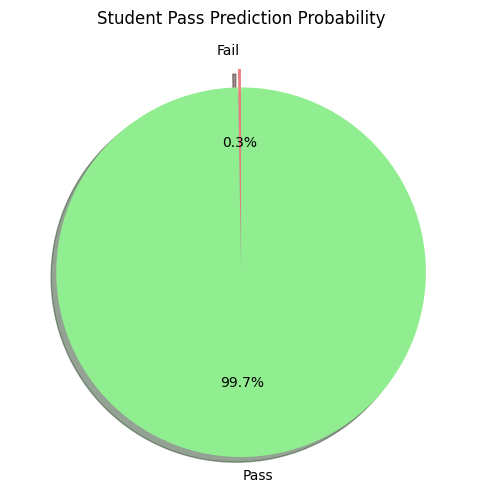

In [4]:
import matplotlib.pyplot as plt
labels = ["Fail", "Pass"]
colors = ["lightcoral", "lightgreen"]

plt.figure(figsize=(6,6))
plt.pie(probability[0],labels=labels,autopct="%1.1f%%",startangle=90,explode=(0.05, 0.05),
        colors=colors,shadow=True)
plt.title("Student Pass Prediction Probability")
plt.show()

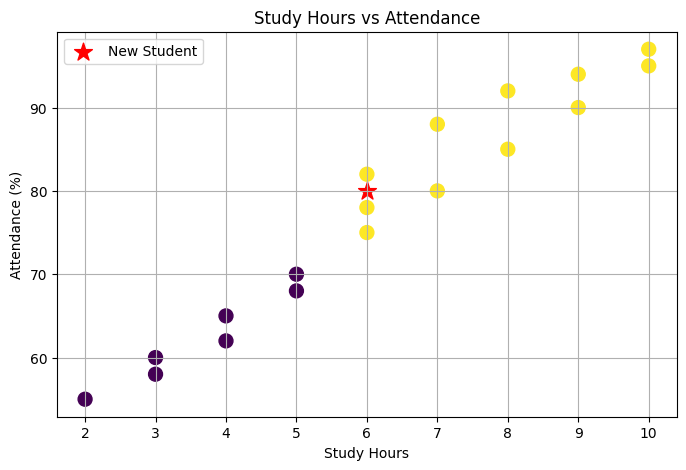

In [5]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(study_hours,attendance,c=passed,s=100)
plt.scatter(new_student[0][0],new_student[0][1],color="red",s=180,
            marker="*",label="New Student")
plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("Study Hours vs Attendance")
plt.grid(True)
plt.legend()
plt.show()